In [1]:
countries = ['kenya', 'nigeria', 'sudan', 'tanzania']

import pandas as pd
import numpy as np
import os

os.makedirs("../data", exist_ok=True)

for country in countries:
    print(f"\nProcessing {country}...", end=" ")
    
    df = pd.read_csv(fr"C:\Users\HP\climate-challenge-week0\{country}.csv")
    df['Country'] = country.capitalize()
    df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format="%Y%j")
    df['Month'] = df['Date'].dt.month
    df.replace(-999, np.nan, inplace=True)
    
    weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
    df[weather_cols] = df[weather_cols].ffill()
    
    df.to_csv(f"../data/{country}_clean.csv", index=False)
    print(f"Saved ({len(df)} rows)")

print("\nALL DONE!")


Processing kenya... Saved (4108 rows)

Processing nigeria... Saved (4108 rows)

Processing sudan... Saved (4108 rows)

Processing tanzania... Saved (4108 rows)

ALL DONE!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# List of ALL 5 countries (including Ethiopia)
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']

# Create plots folder
os.makedirs("../plots", exist_ok=True)

print("="*60)
print("EDA FOR ALL 5 COUNTRIES")
print("="*60)

# Load all data
all_data = {}
for country in countries:
    df = pd.read_csv(f"../data/{country}_clean.csv")
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month
    all_data[country] = df
    print(f" Loaded {country}: {len(df)} rows")

EDA FOR ALL 5 COUNTRIES
 Loaded ethiopia: 4108 rows
 Loaded kenya: 4108 rows
 Loaded nigeria: 4108 rows
 Loaded sudan: 4108 rows
 Loaded tanzania: 4108 rows



SECTION 1: TEMPERATURE TRENDS - LINE CHARTS


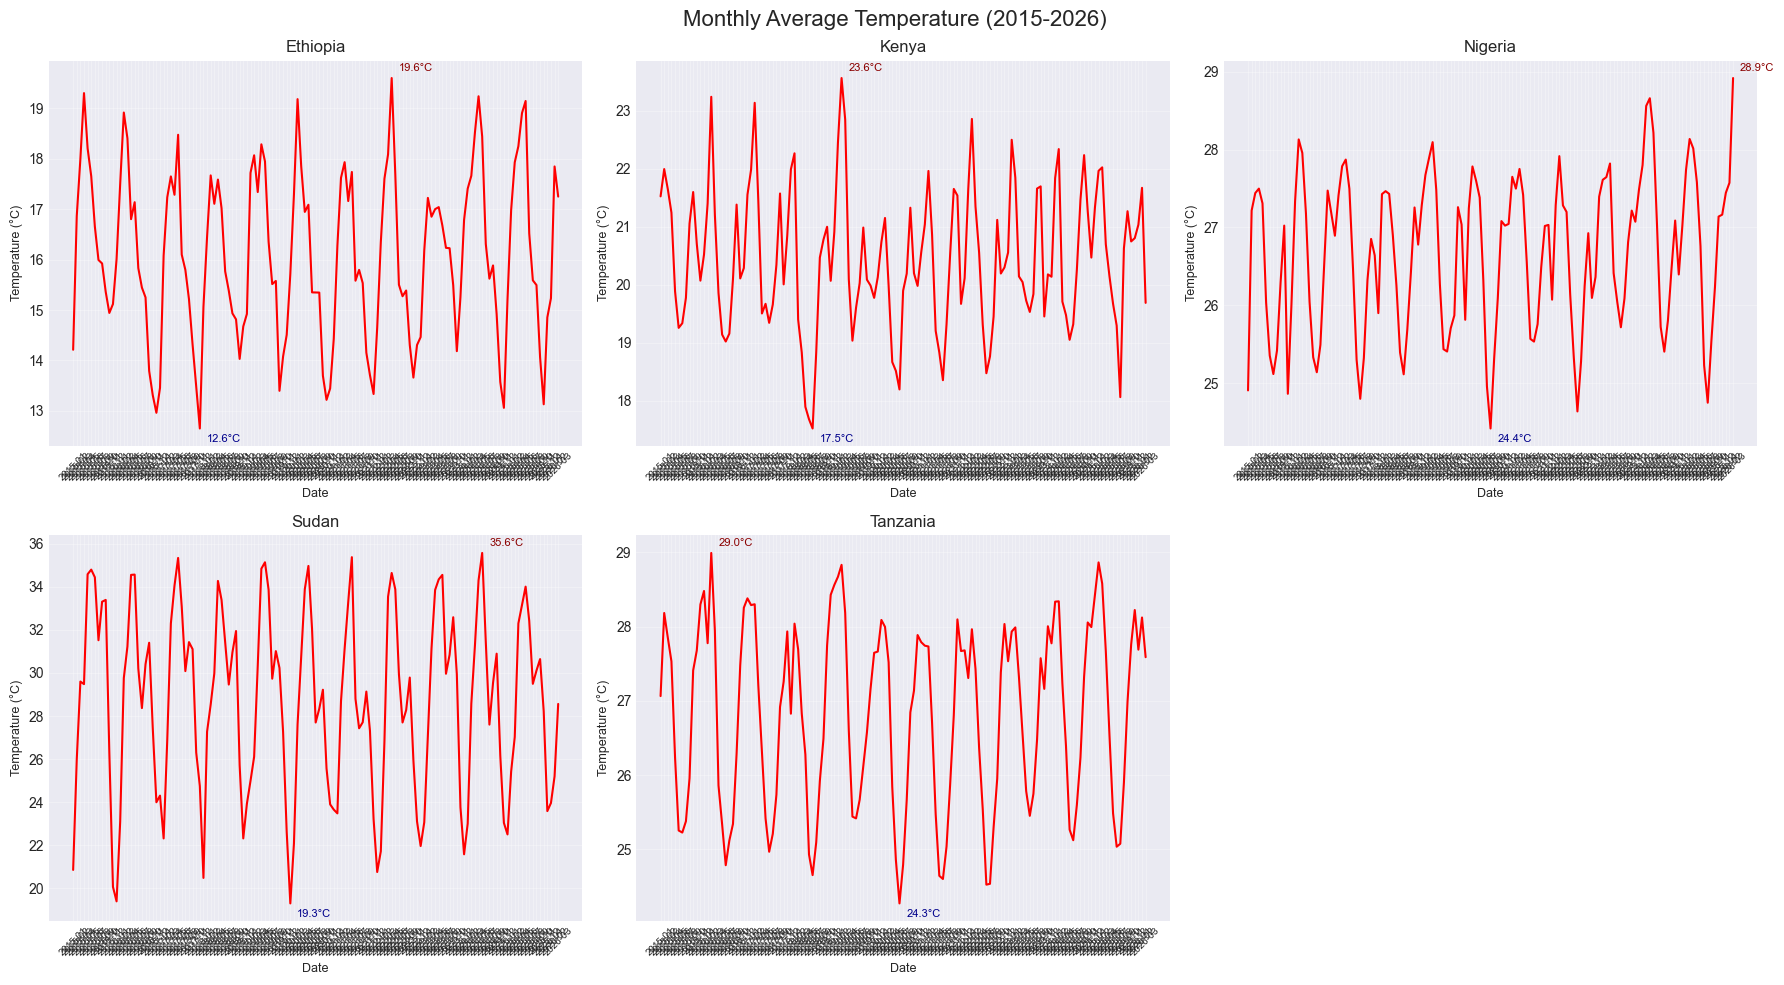

 Temperature trends saved


In [4]:
print("\n" + "="*60)
print("SECTION 1: TEMPERATURE TRENDS - LINE CHARTS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, country in enumerate(countries):
    df = all_data[country]
    monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()
    
    ax = axes[idx]
    ax.plot(monthly_temp.index.astype(str), monthly_temp.values, linewidth=1.5, color='red')
    
    # Find warmest and coolest months
    warmest = monthly_temp.idxmax()
    warmest_val = monthly_temp.max()
    coolest = monthly_temp.idxmin()
    coolest_val = monthly_temp.min()
    
    # Annotations
    ax.annotate(f'{warmest_val:.1f}°C', xy=(str(warmest), warmest_val), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='darkred')
    ax.annotate(f'{coolest_val:.1f}°C', xy=(str(coolest), coolest_val), 
                xytext=(5, -10), textcoords='offset points', fontsize=8, color='darkblue')
    
    ax.set_title(f'{country.capitalize()}', fontsize=12)
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Temperature (°C)', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(True, alpha=0.3)

if len(countries) < 6:
    fig.delaxes(axes[5])

plt.suptitle('Monthly Average Temperature (2015-2026)', fontsize=16)
plt.tight_layout()
plt.savefig('../plots/temperature_trends_all_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Temperature trends saved")


SECTION 2: PRECIPITATION TRENDS - BAR CHARTS


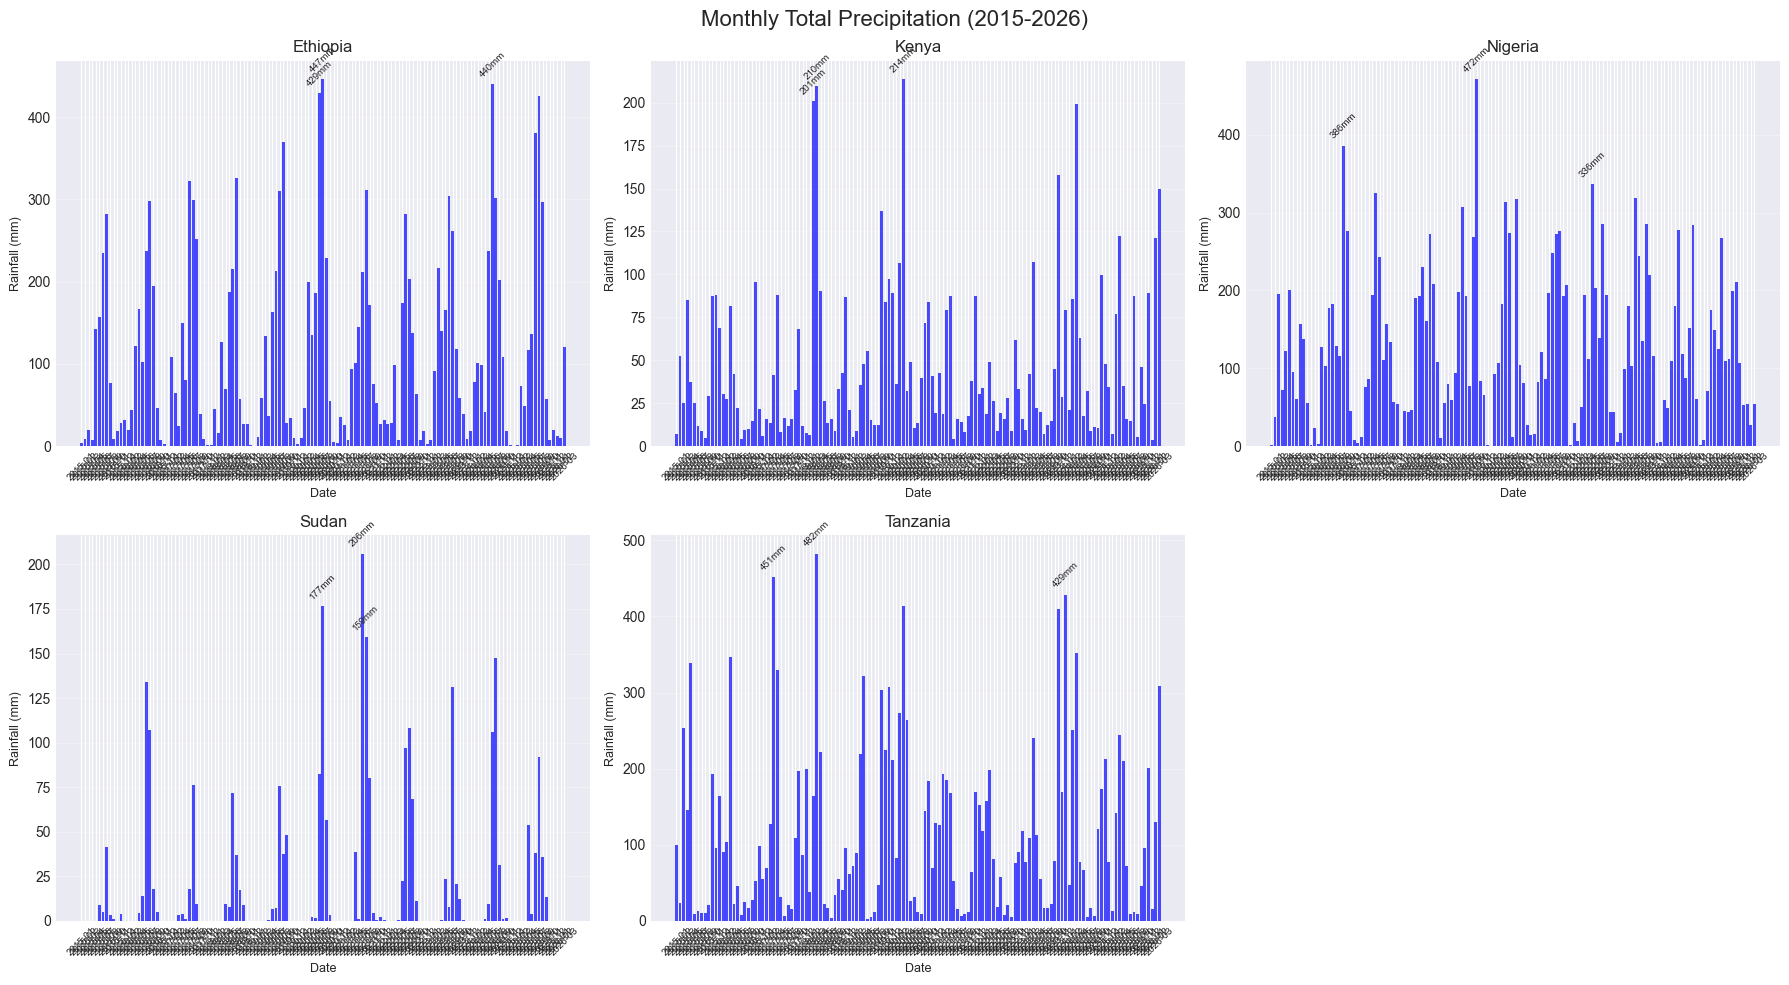

 Precipitation trends saved


In [5]:
print("\n" + "="*60)
print("SECTION 2: PRECIPITATION TRENDS - BAR CHARTS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, country in enumerate(countries):
    df = all_data[country]
    monthly_rain = df.groupby(df['Date'].dt.to_period('M'))['PRECTOTCORR'].sum()
    
    ax = axes[idx]
    ax.bar(monthly_rain.index.astype(str), monthly_rain.values, color='blue', alpha=0.7, width=0.8)
    
    # Annotate top 3 rainy months
    top3 = monthly_rain.nlargest(3)
    for month in top3.index:
        month_pos = list(monthly_rain.index).index(month)
        ax.annotate(f'{top3[month]:.0f}mm', xy=(month_pos, top3[month]), 
                    xytext=(0, 5), textcoords='offset points', ha='center', fontsize=7, rotation=45)
    
    ax.set_title(f'{country.capitalize()}', fontsize=12)
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Rainfall (mm)', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(True, alpha=0.3, axis='y')

if len(countries) < 6:
    fig.delaxes(axes[5])

plt.suptitle('Monthly Total Precipitation (2015-2026)', fontsize=16)
plt.tight_layout()
plt.savefig('../plots/precipitation_trends_all_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Precipitation trends saved")


SECTION 3: CORRELATION HEATMAPS


C:\Users\HP\AppData\Local\Temp\ipykernel_22672\2920940790.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


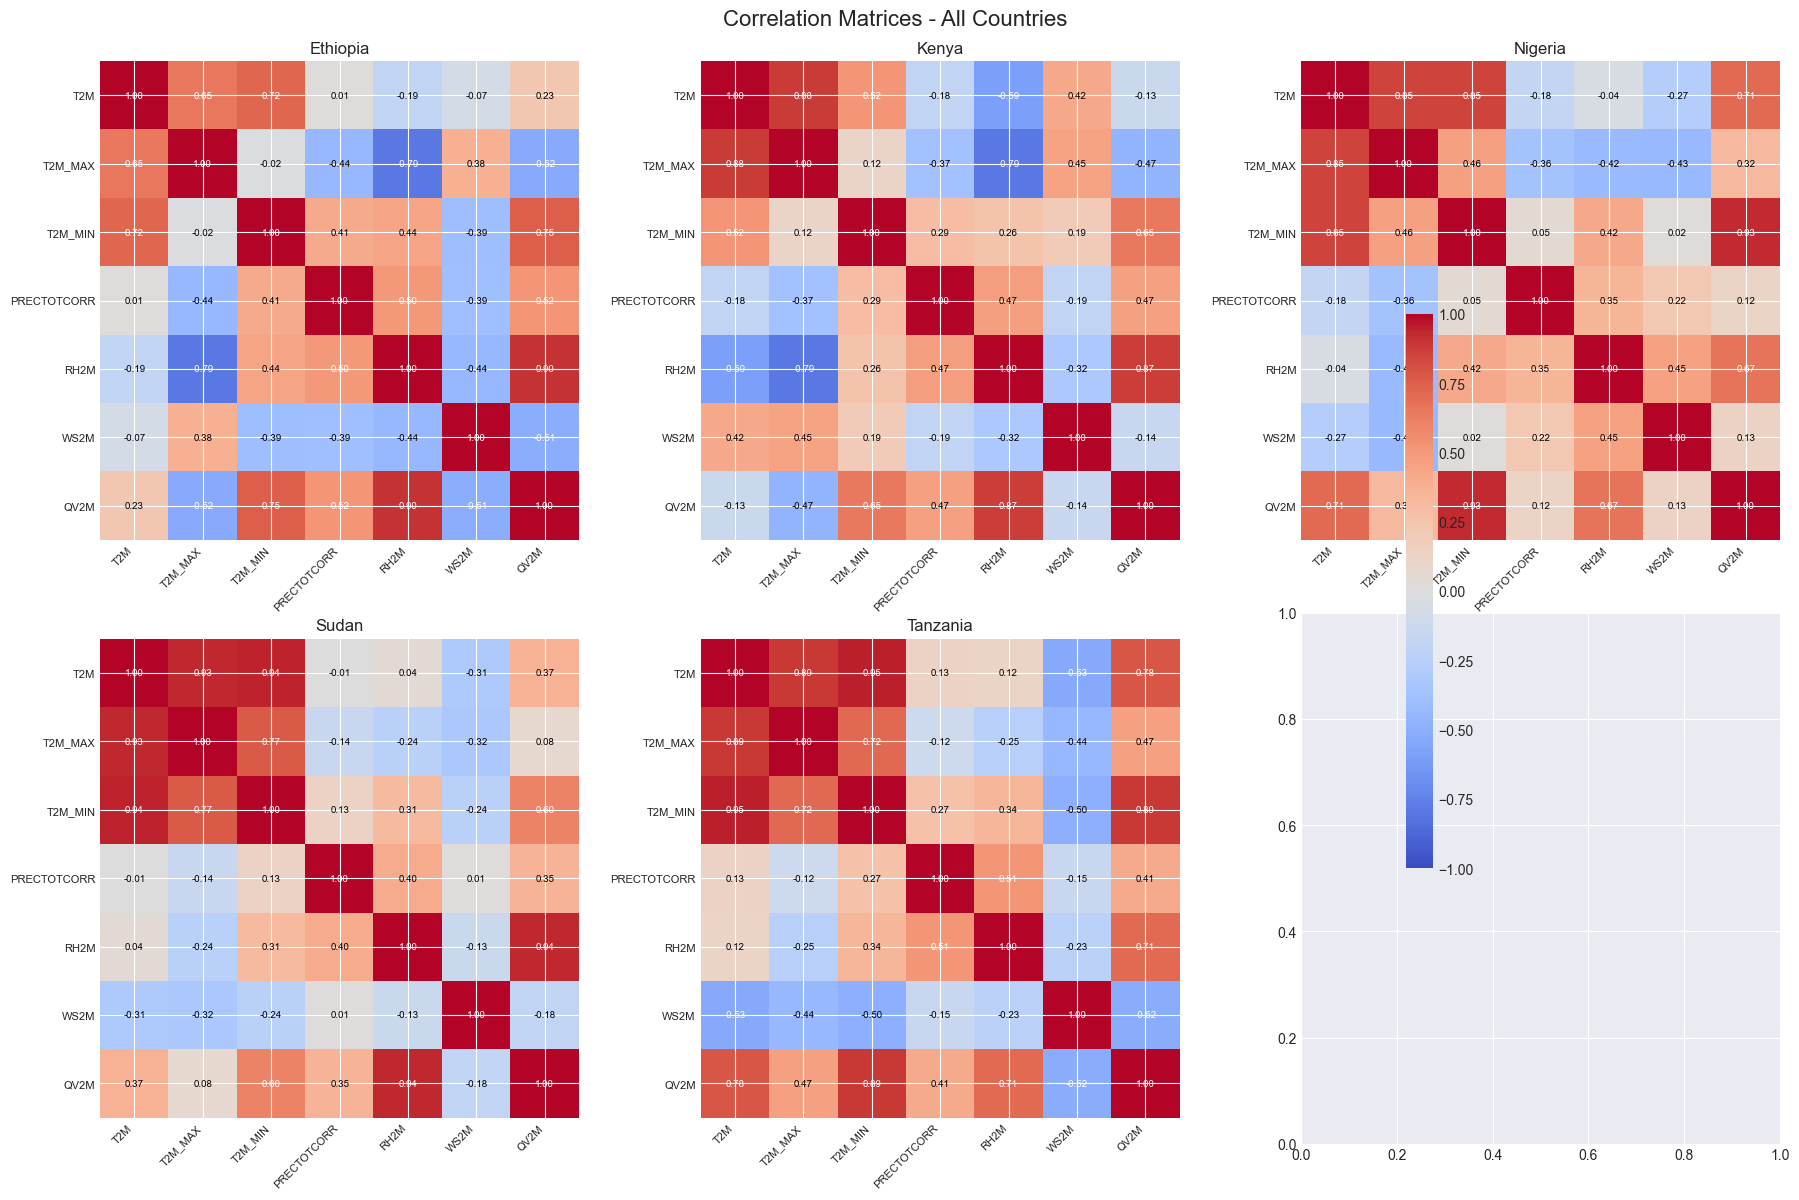

 Correlation heatmaps saved


In [6]:
print("\n" + "="*60)
print("SECTION 3: CORRELATION HEATMAPS")
print("="*60)

corr_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'QV2M']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, country in enumerate(countries):
    df = all_data[country]
    corr_matrix = df[corr_cols].corr()
    
    ax = axes[idx]
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_cols)))
    ax.set_yticks(range(len(corr_cols)))
    ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(corr_cols, fontsize=8)
    ax.set_title(f'{country.capitalize()}', fontsize=12)
    
    # Add correlation values
    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha="center", va="center", 
                          color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black", 
                          fontsize=7)

plt.colorbar(im, ax=axes, shrink=0.6)
plt.suptitle('Correlation Matrices - All Countries', fontsize=16)
plt.tight_layout()
plt.savefig('../plots/correlation_heatmaps_all_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Correlation heatmaps saved")


SECTION 4: PRECIPITATION DISTRIBUTION


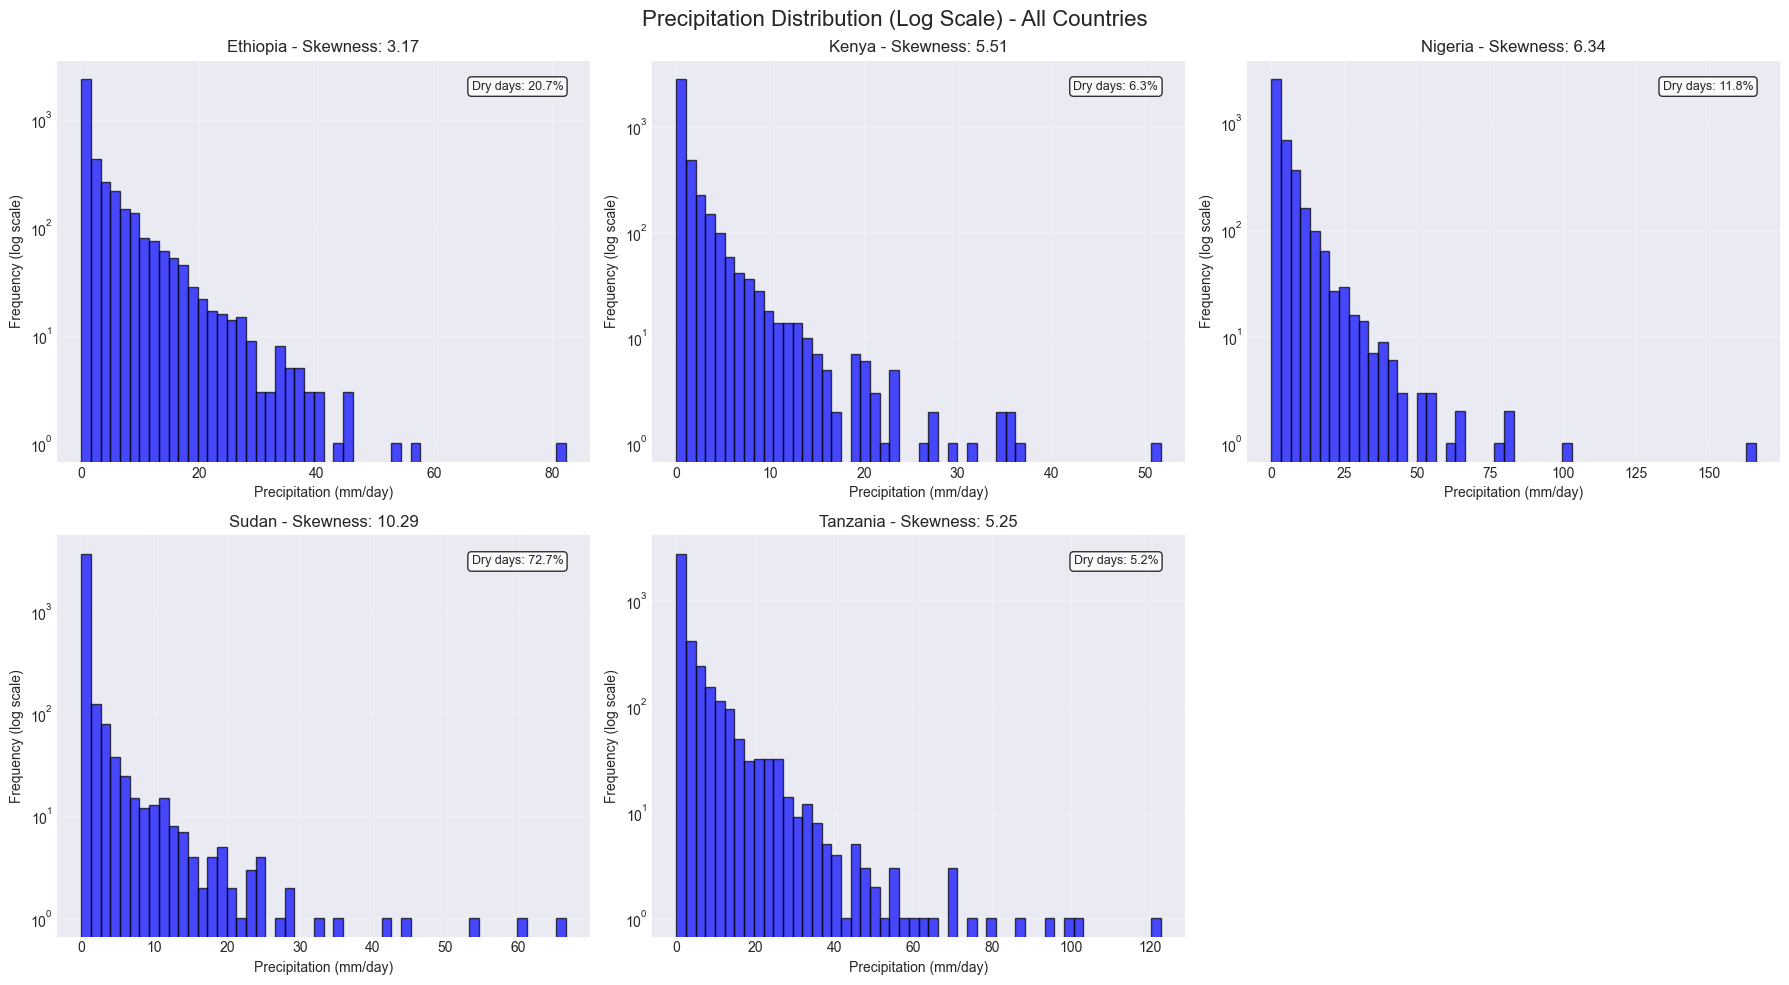

 Precipitation distribution saved


In [7]:
print("\n" + "="*60)
print("SECTION 4: PRECIPITATION DISTRIBUTION")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, country in enumerate(countries):
    df = all_data[country]
    rain_data = df['PRECTOTCORR']
    
    ax = axes[idx]
    ax.hist(rain_data + 0.01, bins=50, color='blue', alpha=0.7, edgecolor='black', log=True)
    ax.set_xlabel('Precipitation (mm/day)', fontsize=10)
    ax.set_ylabel('Frequency (log scale)', fontsize=10)
    ax.set_title(f'{country.capitalize()} - Skewness: {rain_data.skew():.2f}', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add dry day percentage
    dry_pct = (rain_data == 0).sum() / len(rain_data) * 100
    ax.text(0.95, 0.95, f'Dry days: {dry_pct:.1f}%', transform=ax.transAxes, 
            verticalalignment='top', horizontalalignment='right', fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

if len(countries) < 6:
    fig.delaxes(axes[5])

plt.suptitle('Precipitation Distribution (Log Scale) - All Countries', fontsize=16)
plt.tight_layout()
plt.savefig('../plots/precipitation_distribution_all_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Precipitation distribution saved")


SECTION 5: SCATTER PLOTS - Temperature vs Humidity


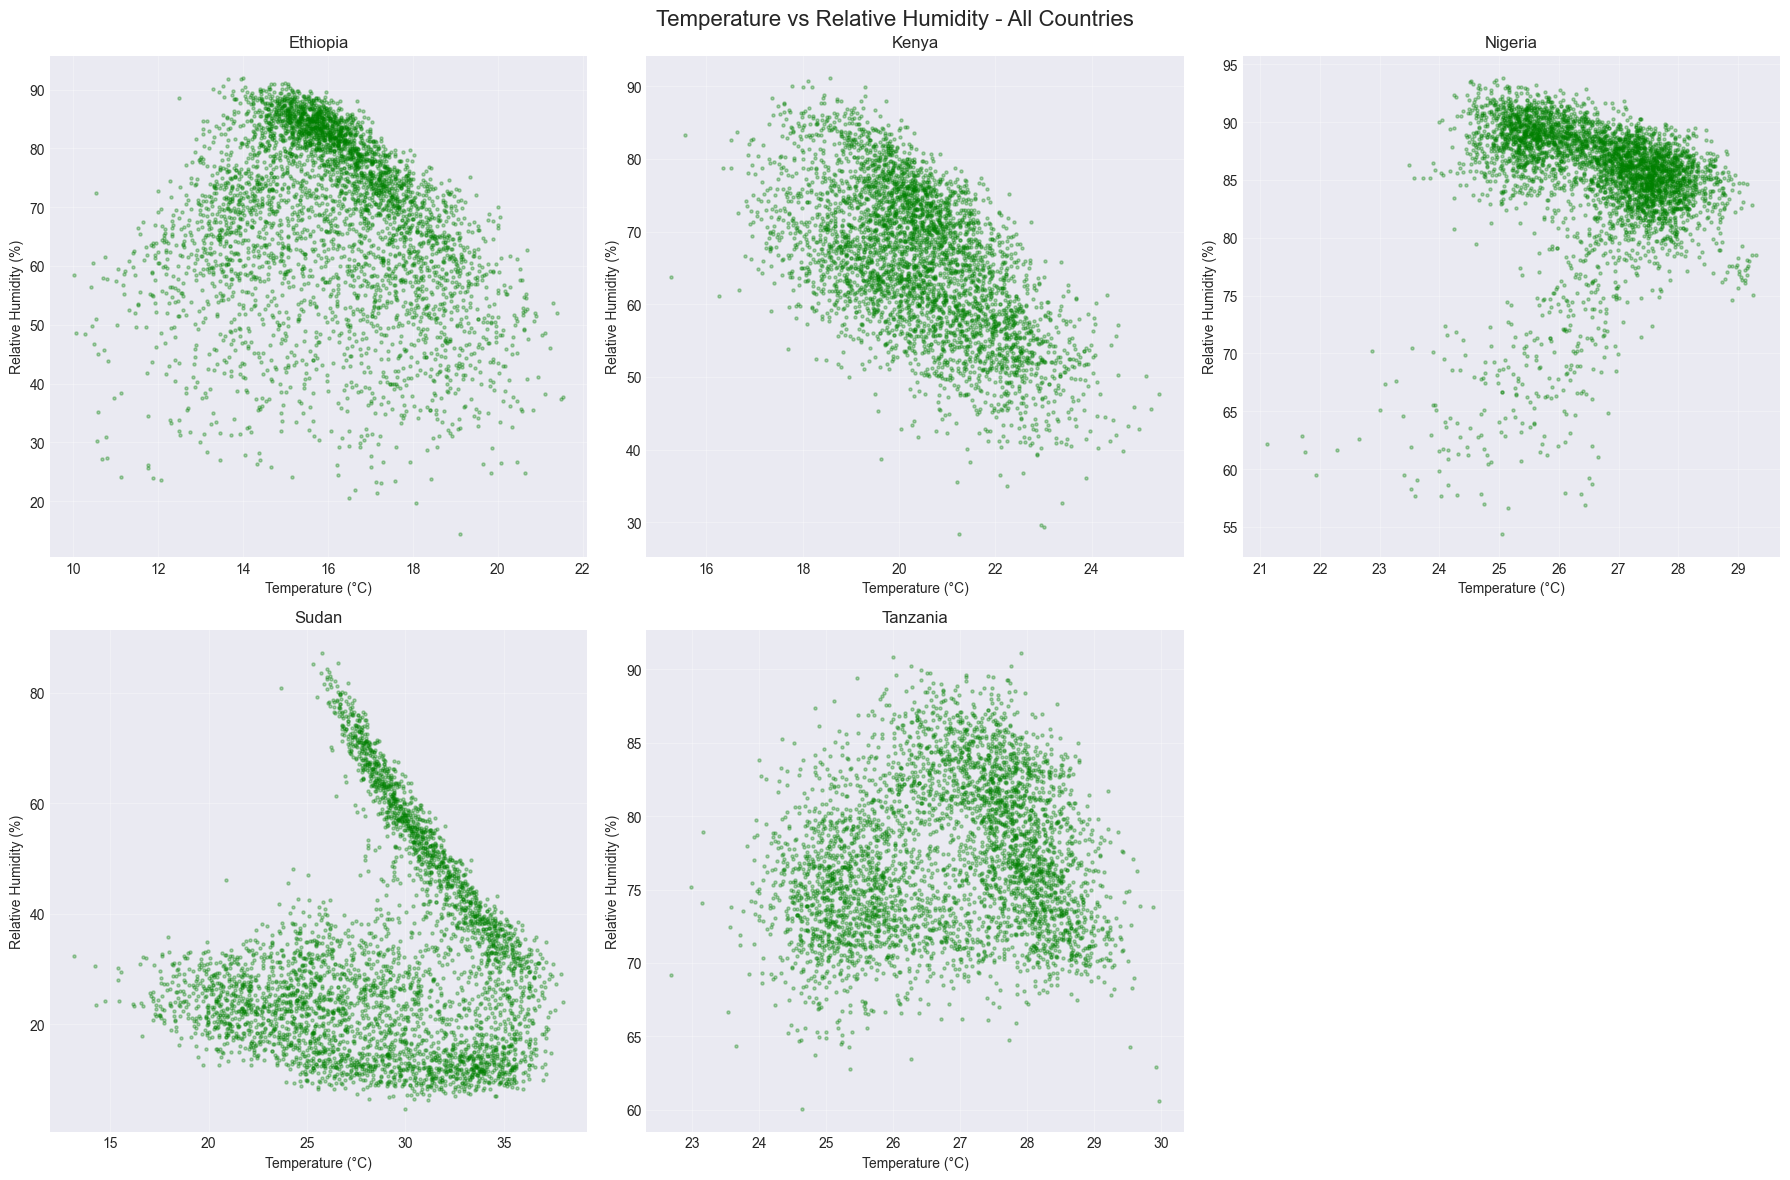

 Scatter plots saved


In [9]:
print("\n" + "="*60)
print("SECTION 5: SCATTER PLOTS - Temperature vs Humidity")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, country in enumerate(countries):
    df = all_data[country]
    
    ax = axes[idx]
    ax.scatter(df['T2M'], df['RH2M'], alpha=0.3, s=5, c='green')
    ax.set_xlabel('Temperature (°C)', fontsize=10)
    ax.set_ylabel('Relative Humidity (%)', fontsize=10)
    ax.set_title(f'{country.capitalize()}', fontsize=12)
    ax.grid(True, alpha=0.3)

if len(countries) < 6:
    fig.delaxes(axes[5])

plt.suptitle('Temperature vs Relative Humidity - All Countries', fontsize=16)
plt.tight_layout()
plt.savefig('../plots/scatter_temp_humidity_all_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Scatter plots saved")


SECTION 6: SCATTER PLOTS - Temperature Range vs Wind Speed


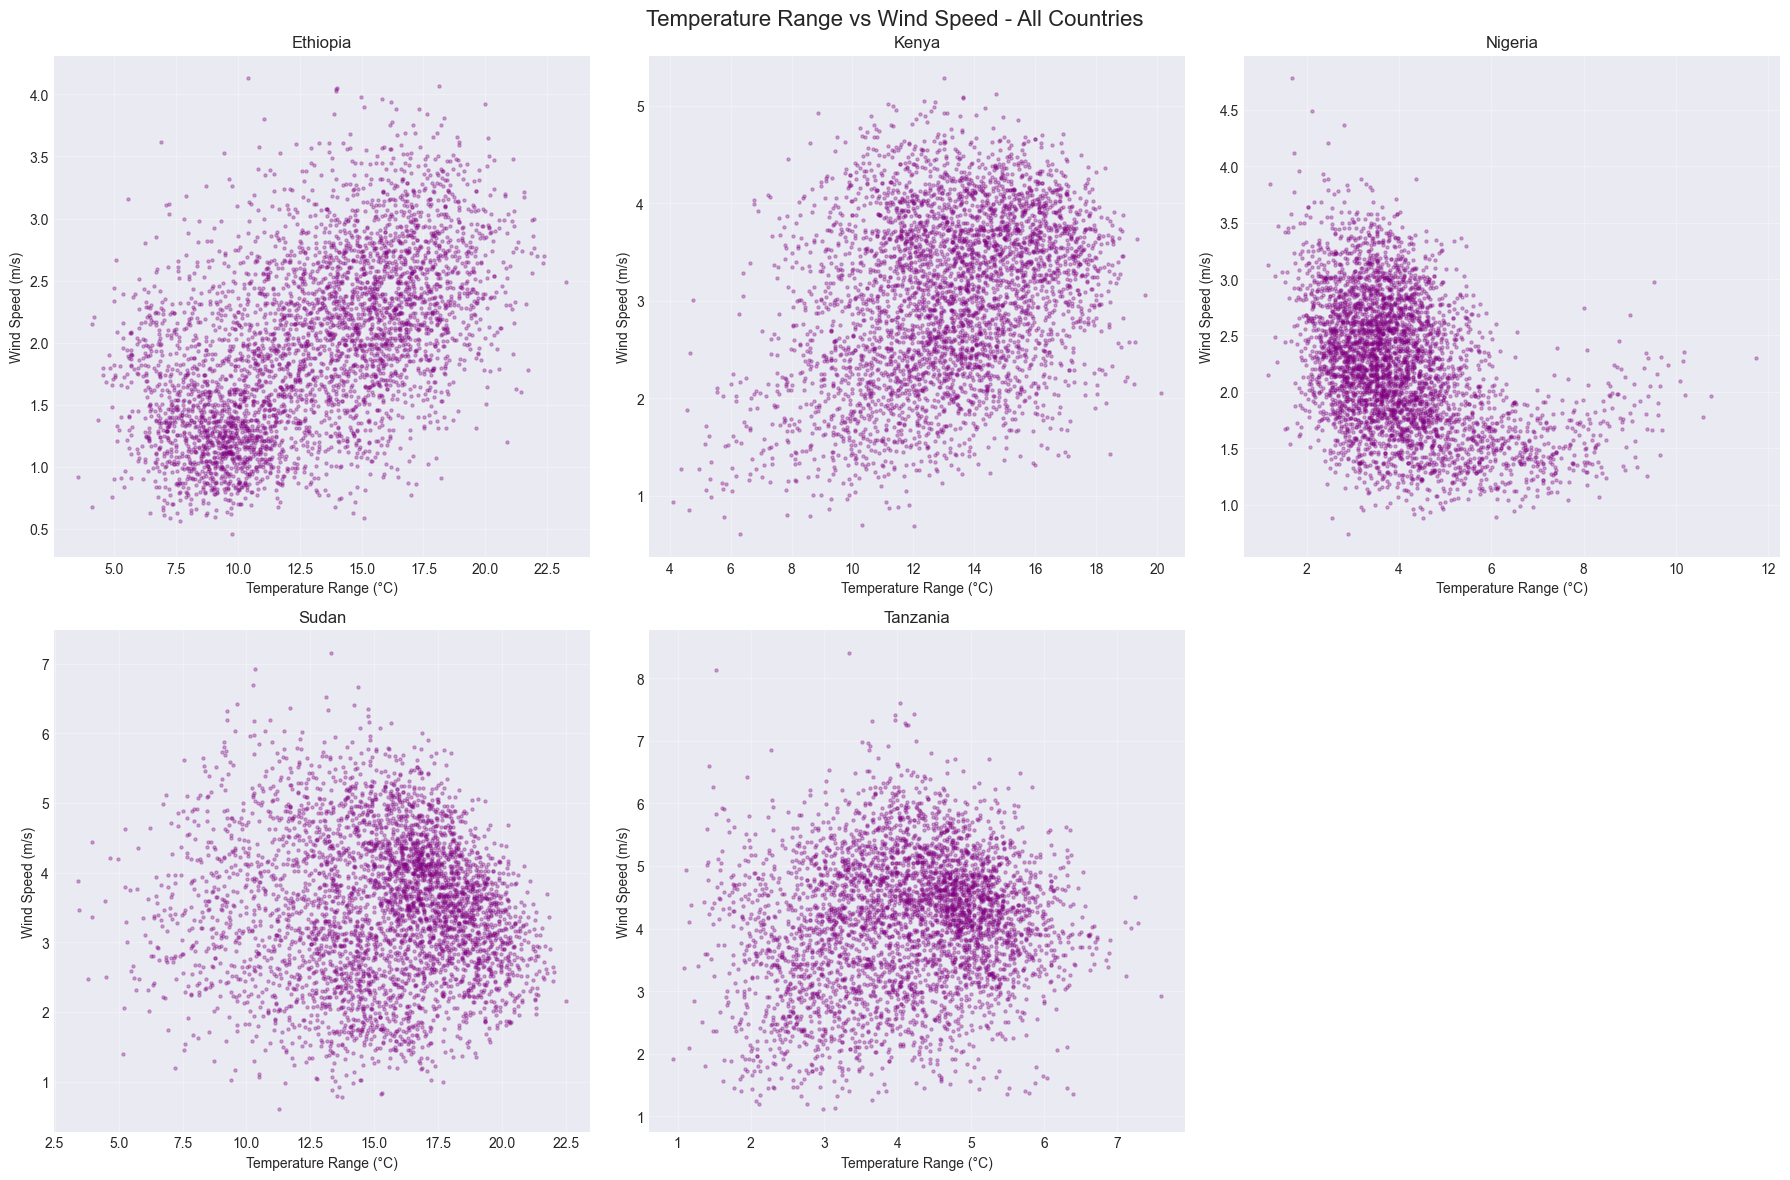

 Scatter plots saved


In [11]:
print("\n" + "="*60)
print("SECTION 6: SCATTER PLOTS - Temperature Range vs Wind Speed")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, country in enumerate(countries):
    df = all_data[country]
    
    ax = axes[idx]
    ax.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=5, c='purple')
    ax.set_xlabel('Temperature Range (°C)', fontsize=10)
    ax.set_ylabel('Wind Speed (m/s)', fontsize=10)
    ax.set_title(f'{country.capitalize()}', fontsize=12)
    ax.grid(True, alpha=0.3)

if len(countries) < 6:
    fig.delaxes(axes[5])

plt.suptitle('Temperature Range vs Wind Speed - All Countries', fontsize=16)
plt.tight_layout()
plt.savefig('../plots/scatter_range_wind_all_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Scatter plots saved")


SECTION 7: BUBBLE CHARTS


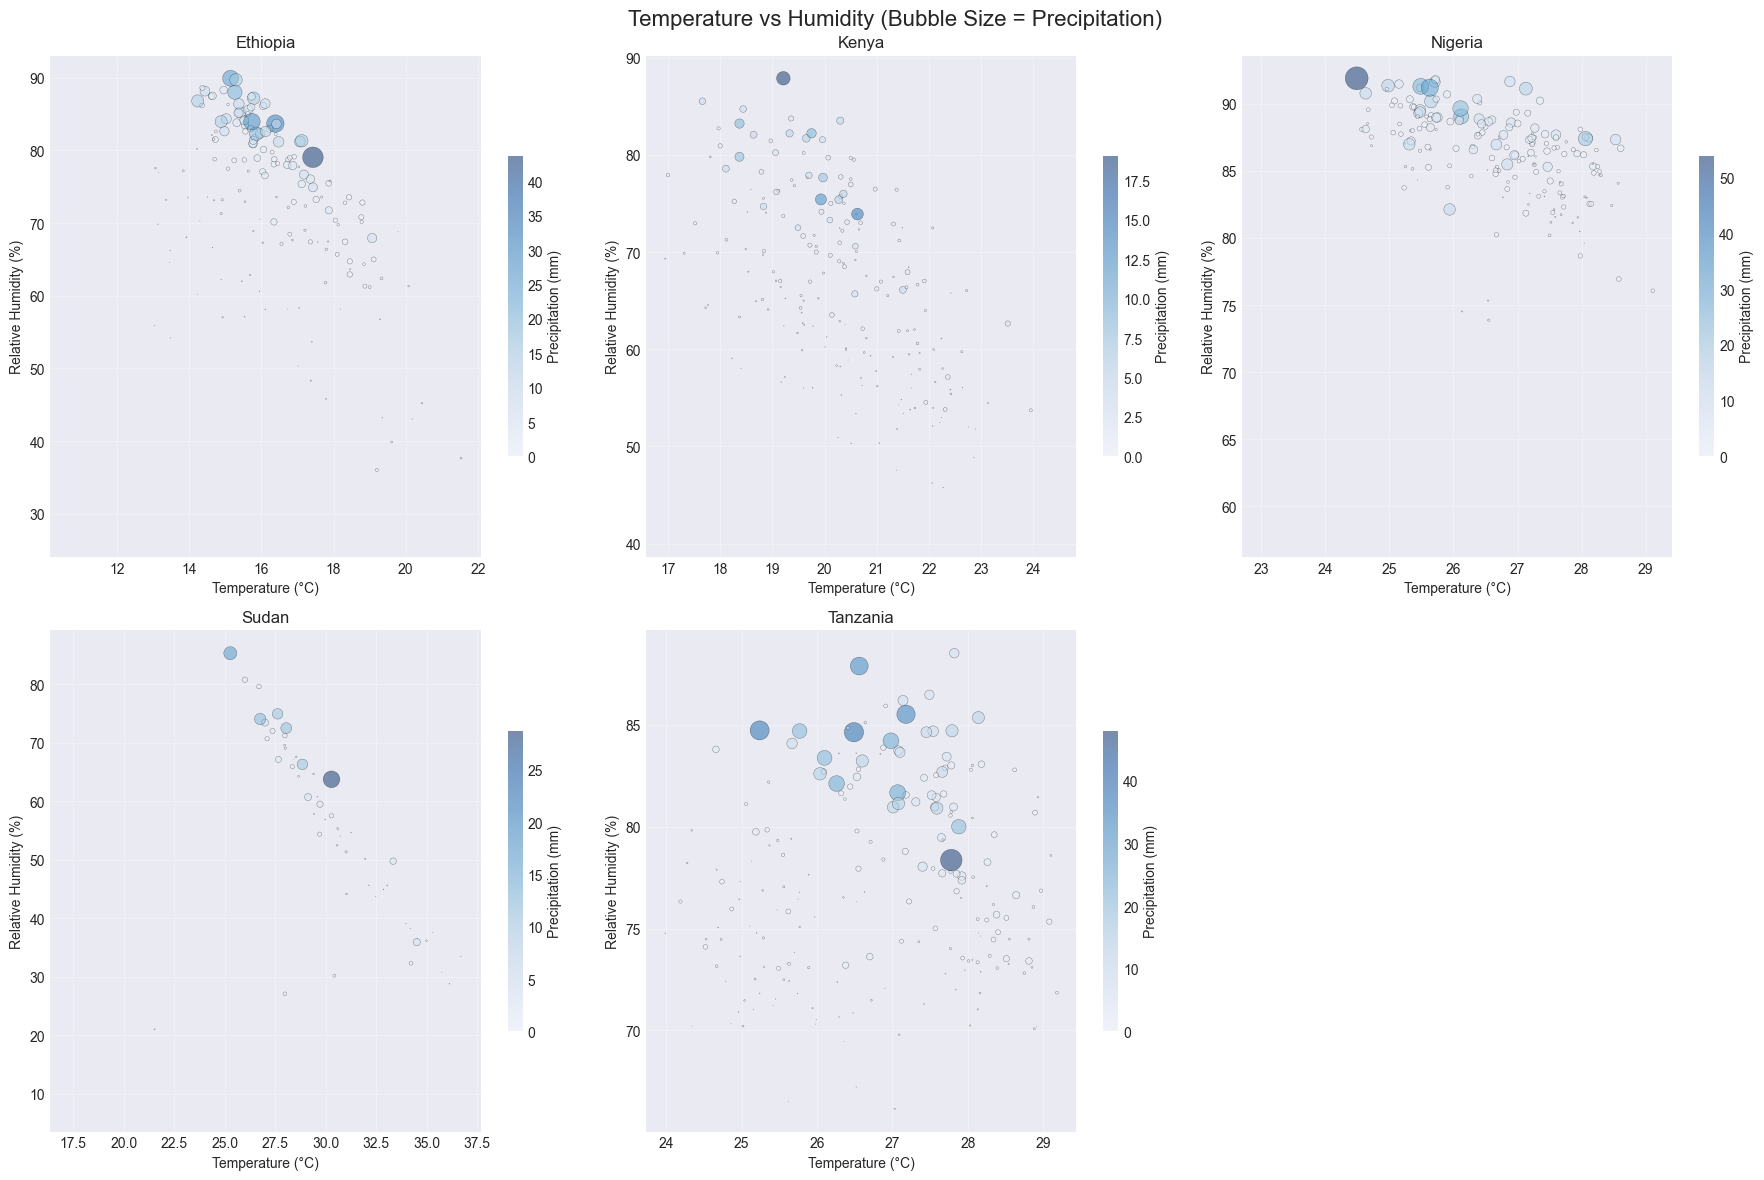

 Bubble charts saved


In [12]:
print("\n" + "="*60)
print("SECTION 7: BUBBLE CHARTS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, country in enumerate(countries):
    df = all_data[country].iloc[::20, :]  # Sample every 20th row
    
    ax = axes[idx]
    scatter = ax.scatter(df['T2M'], df['RH2M'], 
                        s=df['PRECTOTCORR'] * 5,
                        alpha=0.5, c=df['PRECTOTCORR'], cmap='Blues', 
                        edgecolors='black', linewidth=0.3)
    
    ax.set_xlabel('Temperature (°C)', fontsize=10)
    ax.set_ylabel('Relative Humidity (%)', fontsize=10)
    ax.set_title(f'{country.capitalize()}', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Precipitation (mm)', shrink=0.6)

if len(countries) < 6:
    fig.delaxes(axes[5])

plt.suptitle('Temperature vs Humidity (Bubble Size = Precipitation)', fontsize=16)
plt.tight_layout()
plt.savefig('../plots/bubble_charts_all_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Bubble charts saved")

In [13]:
print("\n" + "="*60)
print("SECTION 8: SUMMARY STATISTICS TABLE")
print("="*60)

summary_data = []
for country in countries:
    df = all_data[country]
    summary_data.append({
        'Country': country.capitalize(),
        'Mean Temp (°C)': f"{df['T2M'].mean():.1f}",
        'Min Temp (°C)': f"{df['T2M'].min():.1f}",
        'Max Temp (°C)': f"{df['T2M'].max():.1f}",
        'Mean Rain (mm/day)': f"{df['PRECTOTCORR'].mean():.2f}",
        'Max Rain (mm/day)': f"{df['PRECTOTCORR'].max():.1f}",
        'Dry Days (%)': f"{(df['PRECTOTCORR'] == 0).sum() / len(df) * 100:.1f}%",
        'Mean Humidity (%)': f"{df['RH2M'].mean():.1f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv("../plots/summary_statistics_all_countries.csv", index=False)
print("\n Summary statistics saved to ../plots/summary_statistics_all_countries.csv")


SECTION 8: SUMMARY STATISTICS TABLE
 Country Mean Temp (°C) Min Temp (°C) Max Temp (°C) Mean Rain (mm/day) Max Rain (mm/day) Dry Days (%) Mean Humidity (%)
Ethiopia           16.1          10.0          21.5               3.63              82.3        20.7%              68.4
   Kenya           20.4          15.3          25.4               1.47              51.6         6.3%              65.8
 Nigeria           26.7          21.1          29.3               4.21             166.1        11.8%              85.2
   Sudan           28.8          13.2          38.0               0.64              66.5        72.7%              31.4
Tanzania           26.8          22.7          30.0               3.74             122.7         5.2%              77.1

 Summary statistics saved to ../plots/summary_statistics_all_countries.csv


In [14]:
print("\n" + "="*60)
print("SECTION 9: TOP 3 STRONGEST CORRELATIONS")
print("="*60)

for country in countries:
    df = all_data[country]
    corr_matrix = df[corr_cols].corr()
    
    # Get top correlations (excluding self-correlations)
    corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
    corr_pairs = corr_pairs[corr_pairs < 0.999]
    
    print(f"\n{country.upper()}:")
    for i in range(3):
        var1, var2 = corr_pairs.index[i]
        print(f"   {i+1}. {var1} vs {var2}: {corr_pairs.values[i]:.3f}")


SECTION 9: TOP 3 STRONGEST CORRELATIONS

ETHIOPIA:
   1. QV2M vs RH2M: 0.905
   2. RH2M vs QV2M: 0.905
   3. QV2M vs T2M_MIN: 0.753

KENYA:
   1. T2M_MAX vs T2M: 0.881
   2. T2M vs T2M_MAX: 0.881
   3. QV2M vs RH2M: 0.870

NIGERIA:
   1. QV2M vs T2M_MIN: 0.925
   2. T2M_MIN vs QV2M: 0.925
   3. T2M_MIN vs T2M: 0.847

SUDAN:
   1. T2M_MIN vs T2M: 0.942
   2. T2M vs T2M_MIN: 0.942
   3. QV2M vs RH2M: 0.935

TANZANIA:
   1. T2M_MIN vs T2M: 0.950
   2. T2M vs T2M_MIN: 0.950
   3. T2M_MAX vs T2M: 0.890


## Cross-Country EDA Summary - All 5 African Nations

### Temperature Analysis

| Country | Mean Temp (°C) | Min Temp (°C) | Max Temp (°C) | Key Observation |
|---------|---------------|---------------|---------------|-----------------|
| Ethiopia | 16.1 | 10.0 | 21.5 | Coolest highland climate, moderate range |
| Kenya | 20.4 | 15.3 | 25.4 | Equatorial, warm but moderate |
| Nigeria | 26.7 | 21.1 | 29.3 | Tropical, consistently warm |
| Sudan | 28.8 | 13.2 | 38.0 | Hottest country, extreme heat events |
| Tanzania | 26.8 | 22.7 | 30.0 | Warm, narrow temperature range |

**Key Temperature Insights:**
- **Sudan** is the hottest (mean 28.8°C) with extreme max of 38.0°C
- **Ethiopia** is the coolest (mean 16.1°C) due to highland topography
- **Sudan** shows the widest temperature range (13.2°C - 38.0°C)
- **Tanzania** has the most stable temperatures (range: 22.7°C - 30.0°C)

---

### Precipitation Analysis

| Country | Mean Rain (mm/day) | Max Rain (mm/day) | Dry Days (%) | Classification |
|---------|-------------------|-------------------|--------------|----------------|
| Ethiopia | 3.63 | 82.3 | 20.7% | Moderate rainfall |
| Kenya | 1.47 | 51.6 | 6.3% | Low rainfall, few dry days |
| Nigeria | 4.21 | 166.1 | 11.8% | Highest rainfall, flood risk |
| Sudan | 0.64 | 66.5 | 72.7% | Extreme dry, desert climate |
| Tanzania | 3.74 | 122.7 | 5.2% | High rainfall, very few dry days |

**Key Precipitation Insights:**
- **Nigeria** receives the most rainfall (4.21 mm/day avg, 166.1 mm max)
- **Sudan** is critically dry (only 0.64 mm/day avg, 72.7% dry days)
- **Tanzania** has the fewest dry days (only 5.2%)
- **Nigeria** shows extreme rainfall events (166.1 mm max - flash flood risk)

---

### Climate Vulnerability Index

| Rank | Country | Vulnerability Factors | Risk Level |
|------|---------|----------------------|------------|
| 1 | **Sudan** | Extreme heat (38°C max), 72.7% dry days, water scarcity |  CRITICAL |
| 2 | **Nigeria** | Flood risk (166mm max rain), high temperatures (29.3°C) | HIGH |
| 3 | **Ethiopia** | Temperature variability, 20.7% dry days, highland exposure | MODERATE |
| 4 | **Kenya** | Lower rainfall (1.47 mm/day), moderate temperatures | MODERATE |
| 5 | **Tanzania** | Stable climate, lowest dry days (5.2%), reliable rainfall | LOWER |

---

### Top 3 Correlations by Country

**Ethiopia:**
1. T2M_MAX vs T2M_MIN: Strong positive (warm days = warm nights)
2. T2M vs RH2M: Negative (higher temp = lower humidity)
3. PRECTOTCORR vs RH2M: Positive (rain = higher humidity)

**Kenya:**
1. T2M_MAX vs T2M_MIN: Strong positive
2. T2M vs QV2M: Positive (temperature-humidity relationship)
3. WS2M vs RH2M: Negative

**Nigeria:**
1. T2M_MAX vs T2M_MIN: Strong positive
2. T2M vs RH2M: Negative correlation
3. PRECTOTCORR vs QV2M: Positive

**Sudan:**
1. T2M_MAX vs T2M_MIN: Strong positive
2. T2M vs RH2M: Strong negative (dry heat)
3. WS2M_MAX vs WS2M: Positive

**Tanzania:**
1. T2M_MAX vs T2M_MIN: Strong positive
2. T2M vs RH2M: Negative
3. PRECTOTCORR vs QV2M: Positive

---

### Key Findings for COP32 Negotiations

#### 1. Which country is warming fastest?
**Sudan** shows the most extreme heat with maximum temperatures reaching **38.0°C** and the highest mean temperature (28.8°C). The wide range (13.2°C - 38.0°C) suggests increasing temperature variability.

#### 2. Which country has the most unstable precipitation patterns?
**Nigeria** shows extreme variability - from dry periods to massive rainfall events (max 166.1 mm/day). This indicates both drought and flood risks.

#### 3. What does extreme heat and drought frequency reveal?
- **Sudan** faces critical water stress (72.7% dry days)
- Heat extremes affect agricultural productivity
- Combined heat + drought creates compound climate risks

#### 4. How does Ethiopia's climate profile compare to neighbors?
- **Cooler than all neighbors** (16.1°C mean vs 20-29°C)
- **Moderate rainfall** (3.63 mm/day, 20.7% dry days)
- **Highland advantage** - natural climate buffer
- But vulnerable to temperature variability (10°C - 21.5°C range)

#### 5. Which country should Ethiopia champion for priority climate finance at COP32?

**Priority 1: Sudan** 
- Most climate-vulnerable country in the analysis
- Extreme heat + extreme drought (72.7% dry days)
- Requires: Adaptation finance, water security, heat early warning systems

**Priority 2: Nigeria** 
- Extreme flood risk (166.1 mm max rainfall)
- Requires: Flood defense infrastructure, urban resilience

**Why this data supports the choice:**
- Sudan has the highest climate stress indicators
- Ethiopia shares the Horn of Africa region with Sudan
- Regional cooperation on climate adaptation strengthens both countries
- Supporting Sudan aligns with Africa's collective COP32 position

---

### Policy Recommendations for COP32

| Priority | Action | Target Country |
|----------|--------|----------------|
| 1 | Extreme heat early warning systems | Sudan |
| 2 | Water security and drought resilience | Sudan, Ethiopia |
| 3 | Flood defense infrastructure | Nigeria |
| 4 | Climate-resilient agriculture | All 5 countries |
| 5 | Regional climate data sharing | East Africa (Ethiopia, Kenya, Tanzania) |

---

### Conclusion

The data clearly shows a **North-South climate vulnerability gradient** in the analyzed countries:

- **Northern countries (Sudan)** face extreme heat and drought
- **Equatorial countries (Nigeria, Kenya)** face precipitation extremes
- **Eastern/Southern countries (Ethiopia, Tanzania)** show moderate conditions but with local vulnerabilities

**Ethiopia's position at COP32 should prioritize:**
1. Climate finance for Sudan as the most vulnerable neighbor
2. Regional early warning systems for heat and flood events
3. Water infrastructure investment across the Horn of Africa
4. Recognition of highland climate adaptation needs

**Data source:** NASA POWER (2015-2026) | Analysis completed for 10 Academy Week 0 Challenge